>
> # MaaS Sim tutorial
>
> ## Demand import from ablatross
>
-----

We generate trip requests (`inData.requests`) using data from `Documents/GitHub/MaaSSim_sketches/data/albatross`

Requests are defined through:
* origin (node of `inData.G` graph)
* destinations (node of `inData.G` graph)
* treq (requested departure time)

----

* origins and destinations are drawn as a random node from a given albatross `PC4` zone
* treq is the actual `BT` of the trip

----

This code is syntehsized into functions 'full_albatross(inData)' from `utils/albratross.ipynb`, which can be used in the simulations.


----

Remarks:
* origin and destination are accurate only up to the PC4 postcode, the actual node is drawn randomly
* time is the reported time in the `BT` , `ET` ciolumns of albatross
* some errors may occur in trips (negative travel times)
* we use only internal trips (withing the postcodes belonging to the graph `inData.G`)


In [2]:
import pandas as pd
from shapely.geometry import Point
import os
import matplotlib
import matplotlib.pyplot as plt
import geopandas as gp
import seaborn as sns
import numpy as np
matplotlib.rcParams['figure.figsize'] = [8, 4]

In [1]:
%run ../params.ipynb # parameters dictionary (to be moved to .json)

In [4]:
%run ../utils/utils.ipynb  # generic utilities functions

In [5]:
%run ../dataStructures.ipynb # data structures of tables used in simulations

In [6]:
%run ../utils/gis_utils.ipynb
%run ../utils/plot_utils.ipynb

In [7]:
inData = load_G(inData, stats=True)

In [8]:
params.t0 = pd.Timestamp.now()
inData.stats = networkstats(inData)
inData = generate_demand(inData)

# read data

In [9]:
inData.albatross = DotMap()
for file in os.listdir(params.paths.albatross):
    if file.endswith('.txt'):
        inData.albatross[file.split(".")[0]]=pd.read_csv(os.path.join(params.paths.albatross,file),sep='\t')
        print(file.split(".")[0],inData.albatross[file.split(".")[0]].shape)

AlbModel1 (7998574, 20)
AlbPopulation (1367411, 18)
AlbModel2 (964930, 20)
codes-plans-Albatross (79, 3)


process data

In [10]:
df = pd.concat([inData.albatross.AlbModel1,inData.albatross.AlbModel2])
df.PPC = df.PPC.fillna(0)
df.PPC = df.PPC.astype(int)
inData.albatross.activities = df
print(df.shape)

(8963504, 20)


In [47]:
df.head()

,Hhid_FROM,Day_FROM,Comp_FROM,SEC_FROM,Age_FROM,Child_FROM,Ncars_FROM,Gend_FROM,Wstat_FROM,AgeP_FROM,...,Atype_FROM,With_FROM,BT_FROM,ET_FROM,Home_FROM,PPC_FROM,Mode_FROM,TravTime_FROM,TravDist_FROM,person_id_FROM
0,1,3,1,2,1,0,1,1,2,1,...,9,NaN,300,827.0,1.0,9503,NaN,0.0,NaN,11
1,1,3,1,2,1,0,1,1,2,1,...,0,NaN,841,1717.0,0.0,9643,3.0,14.0,12.72,11
2,1,3,1,2,1,0,1,1,2,1,...,9,NaN,1731,1739.0,1.0,9503,3.0,14.0,12.72,11
3,1,3,1,2,1,0,1,1,2,1,...,6,NaN,1801,1951.0,0.0,9602,3.0,22.0,23.91,11
4,1,3,1,2,1,0,1,1,2,1,...,9,NaN,2013,2700.0,1.0,9503,3.0,22.0,23.91,11


filter data to trips in `G`

In [11]:
inData.PC4 = read_postcodes()[['PC4',"pc4_naam",'geometry']]

assign postcodes to nodes of `inData.G`

In [12]:
inData.gdf_nodes = nodes_gdf(inData.nodes)
inData.gdf_nodes = gp.tools.sjoin(inData.gdf_nodes, inData.PC4[['PC4','geometry']], how="left")

In [13]:
codes = inData.gdf_nodes.PC4.dropna().unique() # unique postcodes in G
codes = set([int(_) for _ in codes])

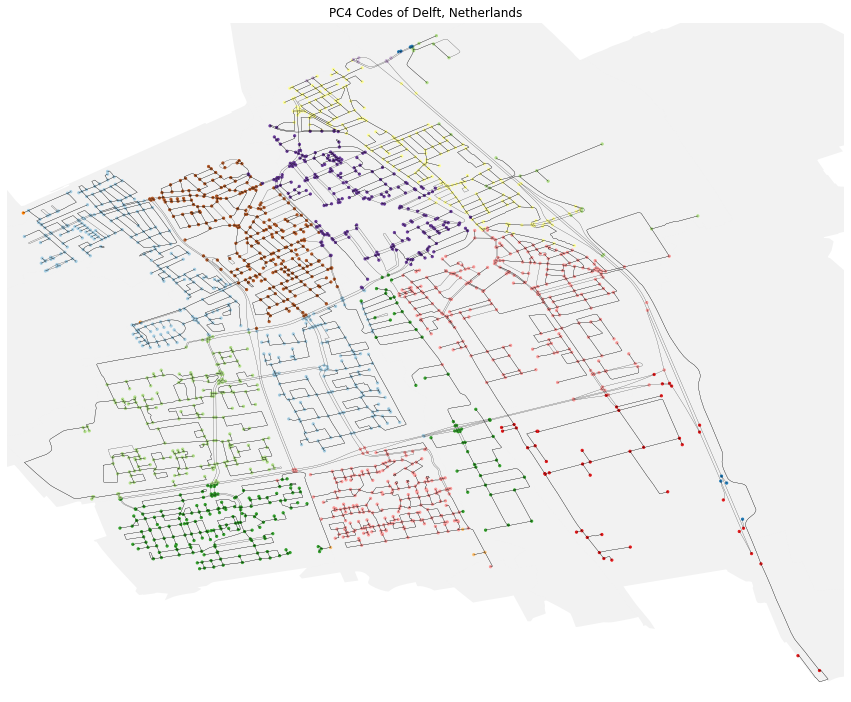

In [14]:
colors = dict(zip(codes,sns.color_palette("Paired", len(codes))))
fig, ax = ox.plot_graph(inData.G, fig_height=15, fig_width=15,node_size=0, edge_linewidth=0.2,
                        show=False, close=False, 
                        edge_color='black')
matplotlib.rcParams['figure.figsize'] = [16, 16]
inData.PC4[inData.PC4.PC4.isin(codes)].plot(color = 'grey', alpha = 0.1, ax = ax)
nodes_with_PC4 = inData.gdf_nodes.loc[inData.gdf_nodes.PC4.dropna().index]
#nodes_with_PC4= nodes_with_PC4[nodes_with_PC4.PC4 == 1013]
nodes_with_PC4['colors'] = nodes_with_PC4.PC4.apply(lambda x: colors[x])
ax.scatter(nodes_with_PC4.geometry.x,nodes_with_PC4.geometry.y, c=nodes_with_PC4['colors'], s=5)  
plt.title('PC4 Codes of {}'.format(params.city))
plt.show()

create trips

In [43]:
df = inData.albatross.activities.copy()
df['person_id']=(df.Hhid*10+df.Gend).astype(int) #unique person id
fs = df.shift(-1)
cols = df.columns 
df.columns = [_+"_FROM" for _ in cols]
cols = fs.columns 
fs.columns = [_+"_TO" for _ in cols]
trips = pd.concat([df,fs], axis = 1)

In [44]:
trips.head()

,Hhid_FROM,Day_FROM,Comp_FROM,SEC_FROM,Age_FROM,Child_FROM,Ncars_FROM,Gend_FROM,Wstat_FROM,AgeP_FROM,...,Atype_TO,With_TO,BT_TO,ET_TO,Home_TO,PPC_TO,Mode_TO,TravTime_TO,TravDist_TO,person_id_TO
0,1,3,1,2,1,0,1,1,2,1,...,0.0,NaN,841.0,1717.0,0.0,9643.0,3.0,14.0,12.72,11.0
1,1,3,1,2,1,0,1,1,2,1,...,9.0,NaN,1731.0,1739.0,1.0,9503.0,3.0,14.0,12.72,11.0
2,1,3,1,2,1,0,1,1,2,1,...,6.0,NaN,1801.0,1951.0,0.0,9602.0,3.0,22.0,23.91,11.0
3,1,3,1,2,1,0,1,1,2,1,...,9.0,NaN,2013.0,2700.0,1.0,9503.0,3.0,22.0,23.91,11.0
4,1,3,1,2,1,0,1,1,2,1,...,9.0,NaN,300.0,707.0,1.0,9501.0,NaN,0.0,NaN,20.0


In [45]:
trips = trips[trips.PPC_TO.isin(codes) & trips.PPC_FROM.isin(codes)] #within params.city

In [17]:
trips = trips[trips.person_id_FROM == trips.person_id_TO] # the same household

In [19]:
trips = trips[trips['BT_TO']>trips['ET_FROM']] # positive travel time

In [46]:
trips.head()

,Hhid_FROM,Day_FROM,Comp_FROM,SEC_FROM,Age_FROM,Child_FROM,Ncars_FROM,Gend_FROM,Wstat_FROM,AgeP_FROM,...,Atype_TO,With_TO,BT_TO,ET_TO,Home_TO,PPC_TO,Mode_TO,TravTime_TO,TravDist_TO,person_id_TO
2992573,449131,5,2,2,1,1,2,0,2,1,...,0.0,NaN,1238.0,1537.0,0.0,2612.0,0.0,5.0,0.0,4491310.0
3033423,455048,5,4,3,1,2,1,1,0,0,...,4.0,NaN,1627.0,1647.0,0.0,2612.0,0.0,5.0,0.0,4550481.0
3089311,464231,3,0,0,0,0,1,0,0,0,...,3.0,NaN,1600.0,1610.0,0.0,2623.0,2.0,5.0,0.0,4642310.0
3102538,466349,4,1,3,0,0,1,0,1,0,...,0.0,NaN,959.0,1558.0,0.0,2611.0,0.0,5.0,0.0,4663490.0
3148609,473609,3,1,3,0,0,1,0,2,0,...,0.0,NaN,1154.0,1548.0,0.0,2289.0,2.0,5.0,0.0,4736090.0


In [26]:
def sample_PC4_node(df,code):
    return df[df.PC4 == code].sample(1).osmid.values[0]

def make_time(df, col):   
    df[col] = df[col].astype(int)
    df = df[df[col].gt(0)] 
    df = df[df[col].lt(2400)]
    df[col] =  pd.to_datetime([str(int(_)).zfill(4) for _ in df[col].values],
                            format = "%H%M")
    return df

In [27]:
t = trips.copy()

pcs = inData.gdf_nodes.groupby('PC4').osmid.apply(list)
t['origin']= t.apply(lambda x: np.random.choice(pcs[x.PPC_TO]), axis=1) 
t['destination']= t.apply(lambda x: np.random.choice(pcs[x.PPC_FROM]), axis=1)

t = make_time(t,'ET_FROM')
t = make_time(t,'BT_TO')
requests = t[['origin','destination','ET_FROM','BT_TO']]
requests.columns = ['origin','destination','treq','tarr']
requests['ttrav'] = (requests.tarr - requests.treq)
inData.requests = requests
inData.requests.head()

/Users/rkucharski/anaconda3/envs/MaaSSim/lib/python3.7/site-packages/ipykernel_launcher.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # This is added back by InteractiveShellApp.init_path()


,origin,destination,treq,tarr,ttrav
2992573,3669138201,1575265336,1900-01-01 11:34:00,1900-01-01 12:38:00,01:04:00
3033423,527378753,44898446,1900-01-01 16:12:00,1900-01-01 16:27:00,00:15:00
3089311,44727971,1668136733,1900-01-01 15:45:00,1900-01-01 16:00:00,00:15:00
3102538,1575265196,44855654,1900-01-01 09:40:00,1900-01-01 09:59:00,00:19:00
3148609,44906763,1402613311,1900-01-01 10:57:00,1900-01-01 11:54:00,00:57:00


In [50]:
inData.requests['dist'] = [inData.skim[request.origin]
                           [request.destination] for _, request in requests.iterrows()]     
t = inData.requests
for i, request in t[t.dist>=params.dist_threshold].iterrows():
    if request.dist >= params.dist_threshold:         #redraw for disconnected trips
        while request.dist >= params.dist_threshold:
            request.origin = np.random.choice(pcs[trips.loc[i].PPC_FROM])
            request.destination = np.random.choice(pcs[trips.loc[i].PPC_TO])
            request.dist = inData.skim[request.origin][request.destination]
            print(request.origin)
        t.loc[i] = request 
requests.ttrav = pd.to_timedelta(requests.ttrav)

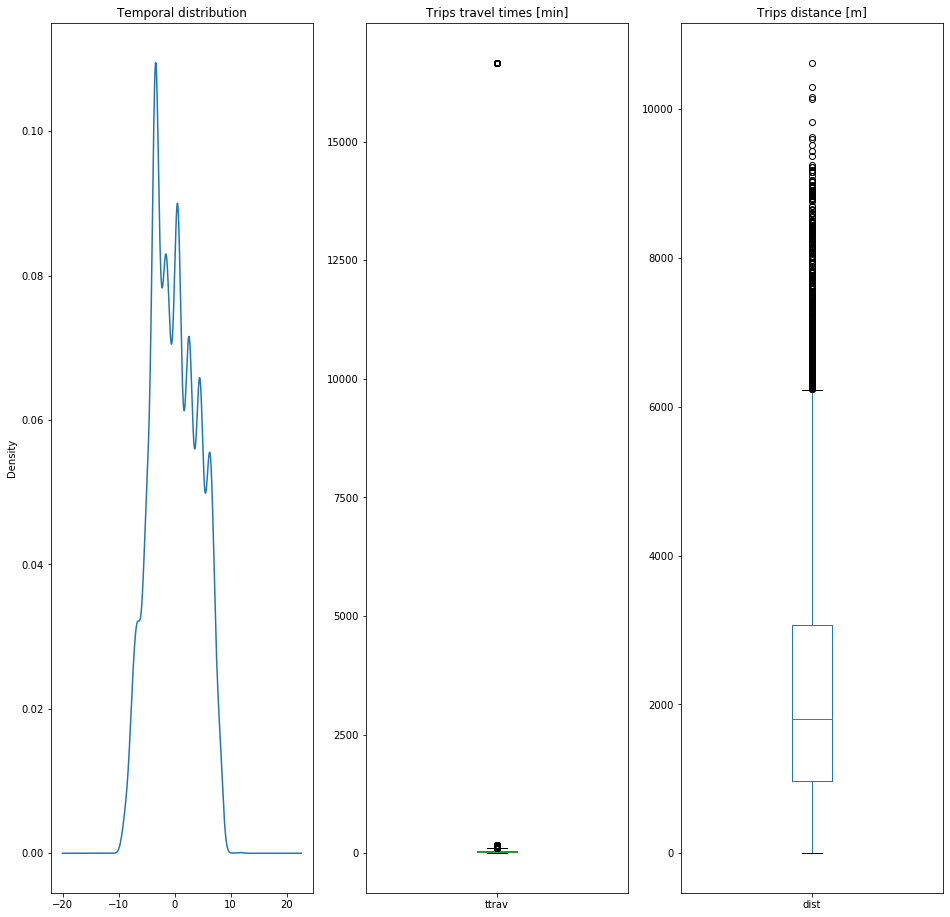

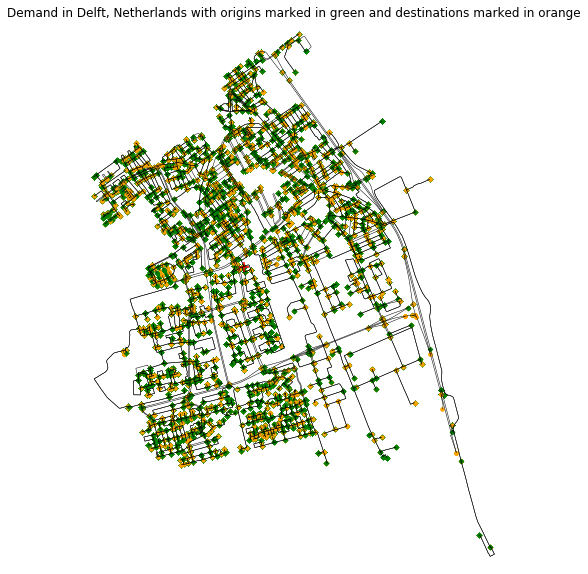

In [51]:
plot_demand(inData)